# Model Training for Fraud Detection

In this notebook we train and evaluate several machine learning models to detect fraudulent transactions.

Models used:
- Logistic Regression
- Random Forest
- XGBoost

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [6]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [7]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC AUC: 0.9720834996210077


In [8]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

threshold = 0.9
y_pred_custom = (y_prob >= threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))

Precision: 0.2471590909090909
Recall: 0.8877551020408163


In [9]:
for t in [0.5, 0.7, 0.8, 0.9, 0.95]:
    y_pred_custom = (y_prob >= t).astype(int)
    print(
        "Threshold:", t,
        "Precision:", precision_score(y_test, y_pred_custom),
        "Recall:", recall_score(y_test, y_pred_custom)
    )

Threshold: 0.5 Precision: 0.06097560975609756 Recall: 0.9183673469387755
Threshold: 0.7 Precision: 0.12125340599455041 Recall: 0.9081632653061225
Threshold: 0.8 Precision: 0.1596330275229358 Recall: 0.8877551020408163
Threshold: 0.9 Precision: 0.2471590909090909 Recall: 0.8877551020408163
Threshold: 0.95 Precision: 0.3901345291479821 Recall: 0.8877551020408163


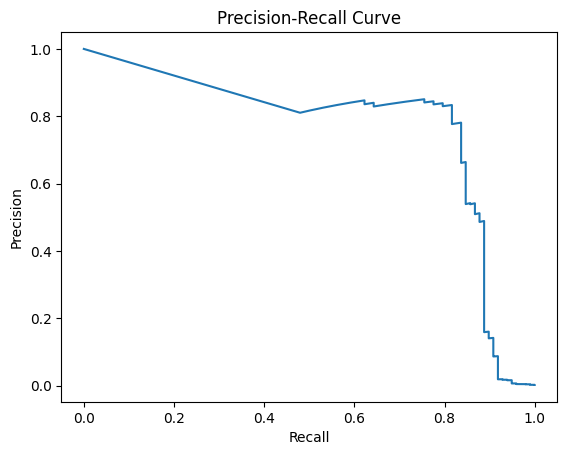

In [10]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

The dataset is extremely imbalanced (0.17% fraud), so Precision-Recall curves are more informative than ROC. The model achieves high recall but precision drops when trying to capture all fraud cases, which is expected in fraud detection systems.

In [11]:
index=X_train.columns

In [12]:
import pandas as pd

feature_importance = pd.Series(
    model.coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

print(feature_importance.head(10))

Amount_scaled    2.367276
V1               1.723862
V14             -1.494961
V4               1.339431
V10             -1.334996
V5               1.214379
V12             -1.127886
V16             -0.996376
V17             -0.992185
V2               0.932075
dtype: float64


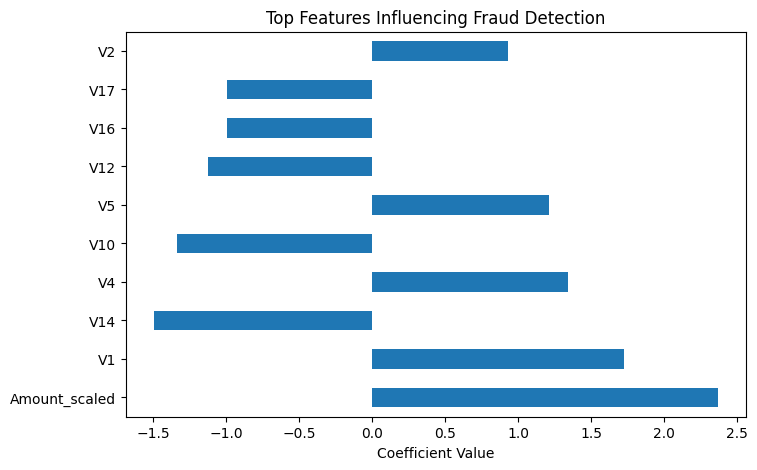

In [13]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind="barh")
plt.title("Top Features Influencing Fraud Detection")
plt.xlabel("Coefficient Value")
plt.show()

The logistic regression model identified variables such as V14, V10 and V12 as strong predictors of fraud. These PCA components capture hidden transaction behavior patterns that differentiate fraudulent activity from legitimate transactions

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [15]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.73      0.83        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9522635640497055


In [16]:
import pandas as pd

importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(10))

V14    0.182583
V4     0.127087
V10    0.123653
V17    0.097536
V12    0.073737
V11    0.068673
V3     0.060208
V7     0.032344
V16    0.029803
V2     0.020669
dtype: float64


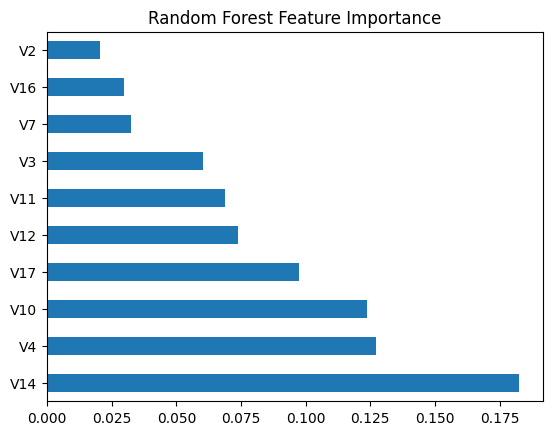

In [17]:
import matplotlib.pyplot as plt

importances.head(10).plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

In [18]:
!pip install xgboost

You should consider upgrading via the '/Users/juanpablodavilamartinez/credit-risk-finance/venv/bin/python3 -m pip install --upgrade pip' command.


In [19]:
from xgboost import XGBClassifier

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=284315/492,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

from sklearn.metrics import classification_report, roc_auc_score

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.973683360513592


In [21]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.973683360513592


XGBoost provided the best balance between fraud detection recall (84%) and precision (87%), outperforming both Logistic Regression and Random Forest in terms of overall model robustness.

In [22]:
import pandas as pd

importances = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(10))

V14              0.569139
V4               0.061660
V12              0.042956
V8               0.026488
V20              0.018046
V7               0.016873
V27              0.016857
Amount_scaled    0.016654
V13              0.016573
V28              0.016307
dtype: float32


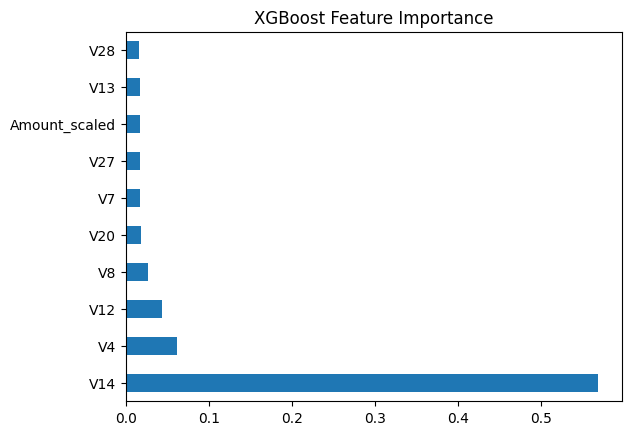

In [23]:
import matplotlib.pyplot as plt

importances.head(10).plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.show()

In [24]:
import joblib

joblib.dump(xgb, "../models/xgboost_fraud_model.pkl")

['../models/xgboost_fraud_model.pkl']

In [27]:
print(X_train.columns)

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled',
       'Time_scaled'],
      dtype='object')


In [28]:
import pandas as pd

nueva_transaccion = pd.DataFrame([{
    "V1": -1.35,
    "V2": 0.25,
    "V3": 1.45,
    "V4": 0.67,
    "V5": -0.23,
    "V6": 0.12,
    "V7": -0.45,
    "V8": 0.10,
    "V9": 0.54,
    "V10": -0.21,
    "V11": 0.12,
    "V12": -0.31,
    "V13": 0.25,
    "V14": -0.44,
    "V15": 0.18,
    "V16": -0.22,
    "V17": 0.30,
    "V18": -0.12,
    "V19": 0.41,
    "V20": -0.05,
    "V21": 0.09,
    "V22": -0.17,
    "V23": 0.03,
    "V24": -0.08,
    "V25": 0.12,
    "V26": -0.04,
    "V27": 0.02,
    "V28": -0.01,
    "Amount_scaled": 0.15,
    "Time_scaled": 0.32
}])

In [29]:
nueva_transaccion = nueva_transaccion[X_train.columns]

In [30]:
pred = xgb.predict(nueva_transaccion)
prob = xgb.predict_proba(nueva_transaccion)[:,1]

print("Prediction:", pred)
print("Fraud probability:", prob)

Prediction: [0]
Fraud probability: [0.00011364]


In [32]:
def detect_fraud(transaction, model):
    pred = model.predict(transaction)
    prob = model.predict_proba(transaction)[:,1]

    if pred[0] == 1:
        print(f" Fraud detected | Probability: {prob[0]:.2f}")
    else:
        print(f" Legitimate transaction | Probability of fraud: {prob[0]:.2f}")

In [33]:
detect_fraud(nueva_transaccion, xgb)

✅ Legitimate transaction | Probability of fraud: 0.00


In [34]:
nueva_transaccion["V14"] = -5
nueva_transaccion["V10"] = -6

In [35]:
xgb.predict_proba(nueva_transaccion)

array([[0.8792322 , 0.12076779]], dtype=float32)